# Import the packages and set the hyperparameters



In [6]:
### it's important to choose how we get to have the labelled data from 25600 datapoints. Are they randomly selected?
### Are they from lhs? Are they evenly disributed?

import tensorflow as tf
import datetime, os
#hide tf logs 
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # or any {'0', '1', '2'} 
#0 (default) shows all, 1 to filter out INFO logs, 2 to additionally filter out WARNING logs, and 3 to additionally filter out ERROR logs
import scipy.optimize
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.mplot3d import Axes3D
import time
from pyDOE import lhs         #Latin Hypercube Sampling
import seaborn as sns 
import codecs, json

# hyperparameters:
foldername = 'run6_minus_initial' # creates a folder with this name in the current path where the results will be saved.
seed = 3
np.random.seed(seed)
tf.random.set_seed(seed)
maxiter = 10000 #8000
N_b = 100 # no. of training data on the boundary
N_f = 10000 # no. of training data inside the domain
N_l = 100 # no. of labelled data for training 
layers = np.array([2,15,15,15,15,1])
initial_lambda2 = 1.0

# orginal:
# method='L-BFGS-B',
# layers = np.array([2,20,20,20,20,20,20,20,20,1])
# 'maxcor': 200, 
# 'ftol': 1 * np.finfo(float).eps,  #The iteration stops when (f^k - f^{k+1})/max{|f^k|,|f^{k+1}|,1} <= ftol
# 'gtol': 5e-8, 
# 'maxfun':  50000, 
# 'maxiter': maxiter,
# 'iprint': -1,   #print update every 50 iterations
# 'maxls': 50


In [7]:
# --- Global plotting style for the whole notebook ---

import matplotlib as mpl
import matplotlib.pyplot as plt

# Hi-DPI output in Jupyter
try:
    get_ipython().run_line_magic("config", "InlineBackend.figure_format = 'retina'")
except Exception:
    pass

mpl.rcParams.update({
    # Sizes (your chosen 15 everywhere)
    'font.size': 15,
    'axes.titlesize': 15,
    'axes.labelsize': 15,
    'xtick.labelsize': 15,
    'ytick.labelsize': 15,
    'legend.fontsize': 15,
    'figure.titlesize': 15,

    # Figure + save defaults
    'figure.figsize': (6.0, 4.0),      # tweak as needed across the thesis
    'figure.dpi': 120,                 # higher dpi for notebooks
    'savefig.dpi': 300,                # print-friendly exports
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.02,

    # Lines, markers, grids
    'lines.linewidth': 2.0,
    'lines.markersize': 5.5,
    'axes.grid': True,
    'grid.alpha': 0.35,
    'grid.linestyle': '--',
    'grid.linewidth': 0.6,

    # Spines and ticks
    'axes.spines.top': True,
    'axes.spines.right': True,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.major.size': 4,
    'ytick.major.size': 4,

    # Legends
    'legend.frameon': False,
    'legend.handlelength': 2.0,

    # Colormap (keeps things consistent if imshow/contours used)
    'image.cmap': 'viridis',

    # Layout
    'figure.autolayout': True,  # similar to calling plt.tight_layout() automatically
})

# Optional: a helper to standardise axis labels/titles quickly
def style_ax(ax, xlabel=None, ylabel=None, title=None, legend=True):
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    if title:  ax.set_title(title)
    if legend and ax.get_legend() is not None:
        ax.legend()

print("✅ Global matplotlib style set for this notebook.")


✅ Global matplotlib style set for this notebook.


# Data Prep

Training and Testing data is prepared from the solution file

In [8]:
newFolder = os.path.join(os.getcwd(), foldername)
if not os.path.exists(newFolder): os.makedirs(newFolder)

# data = scipy.io.loadmat('Data/burgers_shock.mat')   
# data = scipy.io.loadmat('Data/burgers_shock_mu_005_pi.mat') # lambda2 = 0.0015915495
data = scipy.io.loadmat('Data/burgers_shock_IC_sin2pi.mat') # # lambda2 = 0.0031830989 
# data = scipy.io.loadmat('Data/burgers_shock_mu_01_pi.mat')  # lambda2 = 0.0031830989
x = data['x'] # 256 points between -1 and 1 [256x1]
t = data['t'] # 100 time points between 0 and 1 [100x1] 
usol = data['usol'] # solution of 256x100 grid points

X, T = np.meshgrid(x, t) # makes 2 arrays X and T such that u(X[i],T[j])=usol[i][j] are a tuple


# Test Data

Test data includes the entire dataset and helps with the comparison with the PINN predictions.

In [9]:
''' X_u_test = [X[i],T[i]] [25600,2] for interpolation'''
X_u_test = np.hstack((X.flatten()[:,None], T.flatten()[:,None]))
lb = X_u_test[0]  # [-1. 0.]
ub = X_u_test[-1] # [1.  0.99]
u = usol.flatten('F')[:,None] # column-major order

print(len(X_u_test))

25600


# Training Data

Training data contains 3 types of data:

1) **Labelled** data subset: N_l points inside the domain where the (x,t) coordinate and its u solution is assumed given. This subset is necessary in inverse problem PDEs.

2) **Boundary** data subset: N_b points on the boundary where the (x,t) coordinate and its u solution is assumed given.

2) **Residual** data subset: N_f points inside the domain where the (x,t) coordinate (but not its u solution) is assumed given.

In [10]:
def trainingdata(N_b, N_f, N_l):

    '''labelled data inside the domain'''
    
    X_all_labelled = np.hstack((X.flatten()[:,None], T.flatten()[:,None])) # all labelled 25600 X pairs
    print(X_all_labelled)
    u_all_labelled = usol.flatten('F')[:,None] # all 25600 labelled u's
    idx_l = np.random.choice(X_all_labelled.shape[0], N_l, replace=False) # the index of laballed data
    X_labelled = X_all_labelled[idx_l, :] # choose (x,t) pairs from the set X_all_labelled with indices 'idx_l'
    u_labelled = u_all_labelled[idx_l, :] # choose u's from the set u_all_labelled with indices 'idx_l'

    '''the data that should meet the Boundary Conditions'''

    #Initial Condition -1 =< x =<1 and t = 0  
    leftedge_x = np.hstack((X[0,:][:,None], T[0,:][:,None])) #L1
    leftedge_u = usol[:,0][:,None]

    #Boundary Condition x = -1 and 0 =< t =<1
    bottomedge_x = np.hstack((X[:,0][:,None], T[:,0][:,None])) #L2
    bottomedge_u = usol[-1,:][:,None] # bottomedge_u = usol[0,:][:,None]

    #Boundary Condition x = 1 and 0 =< t =<1
    topedge_x = np.hstack((X[:,-1][:,None], T[:,0][:,None])) #L3
    topedge_u = usol[0,:][:,None] # topedge_u = usol[-1,:][:,None]

    all_X_u_train = np.vstack([leftedge_x, bottomedge_x, topedge_x]) # all_X_u_train [456,2] (456 = 256(L1)+100(L2)+100(L3))
    all_u_train = np.vstack([leftedge_u, bottomedge_u, topedge_u])   #and the corresponding u [456x1]

    #choose random N_b points for training
    idx_b = np.random.choice(all_X_u_train.shape[0], N_b, replace=False) # index of boundary points

    X_u_train = all_X_u_train[idx_b, :] #choose indices from  set 'idx_b' (x,t)
    u_train = all_u_train[idx_b,:]      #choose corresponding u

    '''Residual PDE Points'''

    # Latin Hypercube sampling for collocation points 
    # N_f sets of tuples(x,t)
    X_f_train = lb + (ub-lb)*lhs(2, N_f) 
    X_f_train = np.vstack((X_f_train, X_u_train)) # append training points to collocation points 

#     return X_f_train, X_u_train, u_train 
    return X_f_train, X_u_train, u_train, X_labelled, u_labelled


# **Inverse Problem PINN (Physics-Informed Neural Networks)** 

Generates a **PINN** of L hidden layers, each with n neurons. The functions are as follows:
1) **forward**: the NN (neural network) that predicts the output u, given the coordinates (x,t) as input
2) **get_weights**: transforms the NN trainable_variables (NN weights, NN biases, and the PDE parameters) from matrix form to 1D (one-dimensional), as required by the LBFGS optimizer in TensorFlow
3) **set_weights**: transforms the NN weights and biases from  1D to matrix form for making calculations easier.
4) **loss_labelled**: the loss function from the labelled data 
5) **loss_BC**: the loss function from the boundary and initial conditions
6) **loss_PDE**: the loss function from the PDE residuals (this term makes the PINNs unique to a simple function fitting)
7) **loss**: adds up all the 3 terms.
8) **optimizerfunc**: gets the 1D trainable_variables as input then returns the training loss and trainable_variables gradients. (this is the heart of the program)
9) **optimizer_callback**: this function is called after each iteration and makes the training records for later visualization.

In [ ]:
class Sequentialmodel(tf.Module): 
    def __init__(self, layers, name=None):
       
        self.W = []  #Weights and biases
        self.parameters = 0 #total number of parameters
        self.iteration = 0
        self.losss_history = np.array([])
        self.error_history = np.array([])
        self.w_history = np.array([])
        self.lambda2_history = np.array([])
        self.lambda2 = tf.Variable([initial_lambda2], dtype='float64', trainable = True)
        self.parameters += 1
        self.prev_lambda2 = None
        self.stop_due_to_lambda2 = False
        
        for i in range(len(layers) - 1):
            
            input_dim = layers[i]
            output_dim = layers[i+1]
            
            #Xavier standard deviation
            std_dv = np.sqrt((2.0/(input_dim + output_dim)))

            #weights = normal distribution * Xavier standard deviation + 0
            w = tf.random.normal([input_dim, output_dim], dtype = 'float64') * std_dv
            w = tf.Variable(w, trainable=True, name = 'w' + str(i+1))
            b = tf.Variable(tf.cast(tf.zeros([output_dim]), dtype = 'float64'), trainable = True, name = 'b' + str(i+1))                    
            self.W.append(w)
            self.W.append(b)
            self.parameters +=  input_dim * output_dim + output_dim
    
    def forward(self, x):
        
        x = (x-lb)/(ub-lb)        
        a = x
        for i in range(len(layers)-2):            
            z = tf.add(tf.matmul(a, self.W[2*i]), self.W[2*i+1])
            a = tf.nn.tanh(z)            
        a = tf.add(tf.matmul(a, self.W[-2]), self.W[-1]) # For regression, no activation to last layer
        return a
    
    def get_weights(self):

        parameters_1d = []  # [.... W_i,b_i.....  ] 1d array
        
        for i in range (len(layers)-1):
            
            w_1d = tf.reshape(self.W[2*i],[-1])   #flatten weights 
            b_1d = tf.reshape(self.W[2*i+1],[-1]) #flatten biases
            
            parameters_1d = tf.concat([parameters_1d, w_1d], 0) #concat weights 
            parameters_1d = tf.concat([parameters_1d, b_1d], 0) #concat biases
        parameters_1d = tf.concat([parameters_1d, self.lambda2], 0)
        return parameters_1d
        
    def set_weights(self,parameters):
                
        for i in range (len(layers)-1):

            shape_w = tf.shape(self.W[2*i]).numpy() # shape of the weight tensor
            size_w = tf.size(self.W[2*i]).numpy() #size of the weight tensor 
            
            shape_b = tf.shape(self.W[2*i+1]).numpy() # shape of the bias tensor
            size_b = tf.size(self.W[2*i+1]).numpy() #size of the bias tensor 
                        
            pick_w = parameters[0:size_w] #pick the weights 
            self.W[2*i].assign(tf.reshape(pick_w,shape_w)) # assign  
            parameters = np.delete(parameters,np.arange(size_w),0) #delete 
            
            pick_b = parameters[0:size_b] #pick the biases 
            self.W[2*i+1].assign(tf.reshape(pick_b, shape_b)) # assign 
            parameters = np.delete(parameters,np.arange(size_b),0) #delete 
            
        self.lambda2.assign(parameters[0:1]) # assign the PDE parameter
        parameters = np.delete(parameters, np.arange(1), 0) #delete
    
    def loss_labelled(self, x, y):
        loss_l = tf.reduce_mean(tf.square(y-self.forward(x)))
        return loss_l
            
    def loss_BC(self, x, y):
        loss_u = tf.reduce_mean(tf.square(y-self.forward(x)))        
        return loss_u

    def loss_PDE(self, x_to_train_f):
    
        g = tf.Variable(x_to_train_f, dtype = 'float64', trainable = False)

        x_f = g[:, 0:1]
        t_f = g[:, 1:2]

        with tf.GradientTape(persistent=True) as tape:

            tape.watch(x_f)
            tape.watch(t_f)

            g = tf.stack([x_f[:,0], t_f[:,0]], axis=1)   
            z = self.forward(g)
            u_x = tape.gradient(z, x_f)

        u_t = tape.gradient(z, t_f)    
        u_xx = tape.gradient(u_x, x_f)

        del tape

        f = u_t + (self.forward(g))*(u_x) - self.lambda2*u_xx #### why not use z?

        loss_f = tf.reduce_mean(tf.square(f))

        return loss_f
    
    def loss(self, x, y, g, a, b):
        loss_l = self.loss_labelled(a, b)
        loss_u = self.loss_BC(x, y)
        loss_f = self.loss_PDE(g)

        loss = loss_u + loss_f + loss_l
        return loss, loss_u, loss_f, loss_l
    
    def optimizerfunc(self, parameters):
        
        self.set_weights(parameters)
       
        with tf.GradientTape() as tape:
            tape.watch(self.trainable_variables)
            loss_val, loss_u, loss_f, loss_l = self.loss(X_u_train, u_train, X_f_train, X_labelled, u_labelled)  
        grads = tape.gradient(loss_val, self.trainable_variables)
        del tape
        
        grads_1d = [ ] #flatten grads 
        
        for i in range (len(layers)-1):

            grads_w_1d = tf.reshape(grads[2*i], [-1]) #flatten weights 
            grads_b_1d = tf.reshape(grads[2*i+1], [-1]) #flatten biases

            grads_1d = tf.concat([grads_1d, grads_w_1d], 0) #concat grad_weights 
            grads_1d = tf.concat([grads_1d, grads_b_1d], 0) #concat grad_biases
        grads_lambda2_1d = tf.reshape(grads[-1],[-1]) #flatten the gradient vector of PDE parameter (which is the last element) 
        grads_1d = tf.concat([grads_1d, grads_lambda2_1d], 0) #concat grads of lambda2

        return loss_val.numpy(), grads_1d.numpy()
    
    def optimizer_callback(self, parameters):
        self.iteration += 1

        # # compute current relative change in lambda2
        # curr_lambda2 = float(np.reshape(self.lambda2.numpy(), [-1])[0])
        # if self.prev_lambda2 is not None:
        #     rel_change = np.abs(curr_lambda2 - self.prev_lambda2) / (np.abs(self.prev_lambda2) + 1e-12)
        #     if rel_change < 0.001:
        #         print(f'stopping early: |Δλ2|/|λ2_prev|={rel_change:.4f} < 0.001 at iteration {self.iteration}')
        #         self.stop_due_to_lambda2 = True
        #         return True  # this signals L-BFGS-B to stop

        # self.prev_lambda2 = curr_lambda2
        
        loss_value, loss_u, loss_f, loss_l = self.loss(X_u_train, u_train, X_f_train, X_labelled, u_labelled)
        
        u_pred = self.forward(X_u_test)
        error = np.linalg.norm((u-u_pred),2)/np.linalg.norm(u,2)
        self.error_history = np.append(self.error_history, error)
        
        self.w_history = np.append(self.w_history, self.W[0][0][0]) ### putting the probe on a single weight amongst all.
        
        self.losss_history = np.append(self.losss_history, loss_value.numpy())
        print('iteration:', self.iteration, 'lambda2:', self.lambda2[0].numpy(), 'error:', error, 'loss_value:', loss_value.numpy())
        self.lambda2_history = np.append(self.lambda2_history, self.lambda2.numpy())

# *Solution Plot*

# *Model Training and Testing*

A function '**model**' is defined to generate a NN as per the input set of hyperparameters, which is then trained and tested. The L2 Norm of the solution error is returned as a comparison metric

In [12]:
# Training data
X_f_train, X_u_train, u_train, X_labelled, u_labelled = trainingdata(N_b, N_f, N_l)

PINN = Sequentialmodel(layers)

init_params = PINN.get_weights().numpy()

start_time = time.time() 

results = scipy.optimize.minimize(fun = PINN.optimizerfunc, 
                                  x0 = init_params, 
                                  args=(), 
                                  method='L-BFGS-B', 
                                  jac= True,        # If jac is True, fun is assumed to return the gradient along with the objective function
                                  callback = PINN.optimizer_callback, 
                                  options = {'disp': None,
                                            'maxcor': 200, 
                                            'ftol': 1 * np.finfo(float).eps,  #The iteration stops when (f^k - f^{k+1})/max{|f^k|,|f^{k+1}|,1} <= ftol
                                            'gtol': 5e-8, 
                                            'maxfun':  50000, 
                                            'maxiter': maxiter,
                                            'iprint': -1,   #print update every 50 iterations
                                            'maxls': 50})

elapsed = time.time() - start_time     
print(f'time (min): {elapsed/60.}')         

[[-1.          0.        ]
 [-0.99215686  0.        ]
 [-0.98431373  0.        ]
 ...
 [ 0.98431373  0.99      ]
 [ 0.99215686  0.99      ]
 [ 1.          0.99      ]]


C:\Users\lenovo\AppData\Local\Temp\ipykernel_11780\1336454245.py:10: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  results = scipy.optimize.minimize(fun = PINN.optimizerfunc,


iteration: 1 lambda2: 0.9997101998491719 error: 0.9622044832738502 loss_value: 0.44439197802083014
iteration: 2 lambda2: 0.9995026860672641 error: 0.9597359864314366 loss_value: 0.44400742403860743
iteration: 3 lambda2: 0.9980488483252701 error: 0.9501498091026495 loss_value: 0.4427443978844694
iteration: 4 lambda2: 0.99587330148703 error: 0.9443385759384254 loss_value: 0.44177953158809036
iteration: 5 lambda2: 0.9872645612987125 error: 0.9384226022820198 loss_value: 0.43953173150596936
iteration: 6 lambda2: 0.9757439880827372 error: 0.9372542023052038 loss_value: 0.437943639963725
iteration: 7 lambda2: 0.9716986901844749 error: 0.9369262782212798 loss_value: 0.4371363494368217
iteration: 8 lambda2: 0.9676868463026518 error: 0.938075516242577 loss_value: 0.43695325462815526
iteration: 9 lambda2: 0.966165476387172 error: 0.9380674796429842 loss_value: 0.43688367729873334
iteration: 10 lambda2: 0.9606397673706414 error: 0.9374942097098845 loss_value: 0.43671317252188135
iteration: 11 lam

In [13]:
def solutionplot(u_pred, X_u_train, u_train, X_labelled, u_labelled):
    
    fig, ax = plt.subplots()
    ax.axis('off')

    gs0 = gridspec.GridSpec(1, 4)
    gs0.update(top=1-0.06, bottom=1-1/3, left=0.15, right=0.85, wspace=1)
    ax = plt.subplot(gs0[:, :])

    h = ax.imshow(u_pred, interpolation='nearest', cmap='rainbow', 
                extent=[T.min(), T.max(), X.min(), X.max()], 
                origin='lower', aspect='auto')
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(h, cax=cax)
    
    ax.plot(X_u_train[:,1], X_u_train[:,0], 'kx', label = f'Boundary data ({u_train.shape[0]} points)', markersize = 4, clip_on = False)
    ax.plot(X_labelled[:,1], X_labelled[:,0], 'o', color ='black', label = f'Labelled data ({u_labelled.shape[0]} points)', markersize = 0.1, clip_on = False)

    line = np.linspace(x.min(), x.max(), 2)[:,None]
    ax.plot(t[25]*np.ones((2,1)), line, 'w-', linewidth = 2)
    ax.plot(t[50]*np.ones((2,1)), line, 'w-', linewidth = 2)
    ax.plot(t[75]*np.ones((2,1)), line, 'w-', linewidth = 2)    

    ax.set_xlabel('$t$')
    ax.set_ylabel('$x$')
    ax.legend(frameon=False, loc = 'best')
    ax.set_title('$u(x,t)$', fontsize = 10)
    
    ''' 
    Slices of the solution at points t = 0.25, t = 0.50 and t = 0.75
    '''
    
    ####### Row 1: u(t,x) slices ##################
    gs1 = gridspec.GridSpec(1, 3)
    gs1.update(top=1-1/3, bottom=0, left=0.1, right=0.9, wspace=0.5)

    ax = plt.subplot(gs1[0, 0])
    ax.plot(x,usol.T[25,:], 'b-', linewidth = 2, label = 'Exact')       
    ax.plot(x,u_pred.T[25,:], 'r--', linewidth = 2, label = 'Prediction')
    ax.set_xlabel('$x$')
    ax.set_ylabel('$u(x,t)$')    
    ax.set_title('$t = 0.25s$', fontsize = 10)
    ax.axis('square')
    ax.set_xlim([-1.1,1.1])
    ax.set_ylim([-1.1,1.1])

    ax = plt.subplot(gs1[0, 1])
    ax.plot(x,usol.T[50,:], 'b-', linewidth = 2, label = 'Exact')       
    ax.plot(x,u_pred.T[50,:], 'r--', linewidth = 2, label = 'Prediction')
    ax.set_xlabel('$x$')
    ax.set_ylabel('$u(x,t)$')
    ax.axis('square')
    ax.set_xlim([-1.1,1.1])
    ax.set_ylim([-1.1,1.1])
    ax.set_title('$t = 0.50s$', fontsize = 10)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.35), ncol=5, frameon=False)

    ax = plt.subplot(gs1[0, 2])
    ax.plot(x,usol.T[75,:], 'b-', linewidth = 2, label = 'Exact')       
    ax.plot(x,u_pred.T[75,:], 'r--', linewidth = 2, label = 'Prediction')
    ax.set_xlabel('$x$')
    ax.set_ylabel('$u(x,t)$')
    ax.axis('square')
    ax.set_xlim([-1.1,1.1])
    ax.set_ylim([-1.1,1.1])    
    ax.set_title('$t = 0.75s$', fontsize = 10)
    plt.savefig(os.path.join(newFolder, 'Burgers.png'), dpi = 500)

  message: STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT
  success: False
   status: 1
      fun: 0.0008650232805235248
        x: [-5.297e-01  2.728e+00 ...  1.121e+00  5.676e-03]
      nit: 10000
      jac: [ 1.685e-04 -4.208e-05 ...  5.141e-04 -4.384e-03]
     nfev: 10703
     njev: 10703
 hess_inv: <782x782 LbfgsInvHessProduct with dtype=float64>
Test Error: 0.06677


C:\Users\lenovo\AppData\Local\Temp\ipykernel_11780\2123984325.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(os.path.join(newFolder, 'Burgers.png'), dpi = 500)
C:\Users\lenovo\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


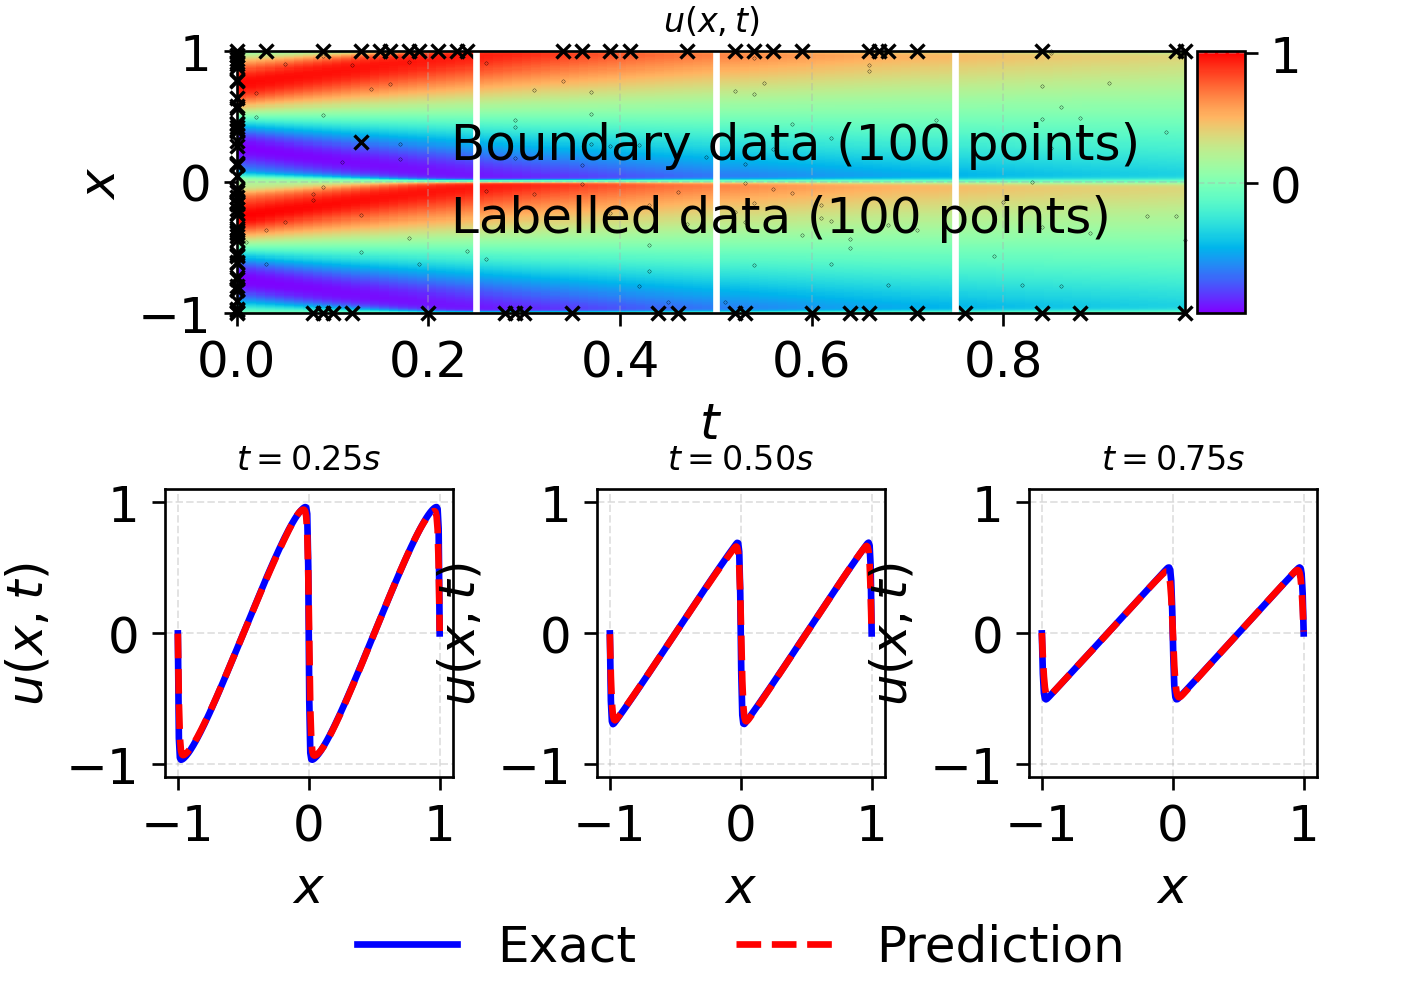

In [14]:
print(results)

PINN.set_weights(results.x)

''' Model Accuracy ''' 
u_pred = PINN.forward(X_u_test)

error_vec = np.linalg.norm((u-u_pred),2)/np.linalg.norm(u,2)        # Relative L2 Norm of the error (Vector)
print('Test Error: %.5f'  % (error_vec))

u_pred = np.reshape(u_pred, (256,100), order='F')                        # column-major order

''' Solution Plot '''
solutionplot(u_pred, X_u_train, u_train, X_labelled, u_labelled)

# Plot of collocation points

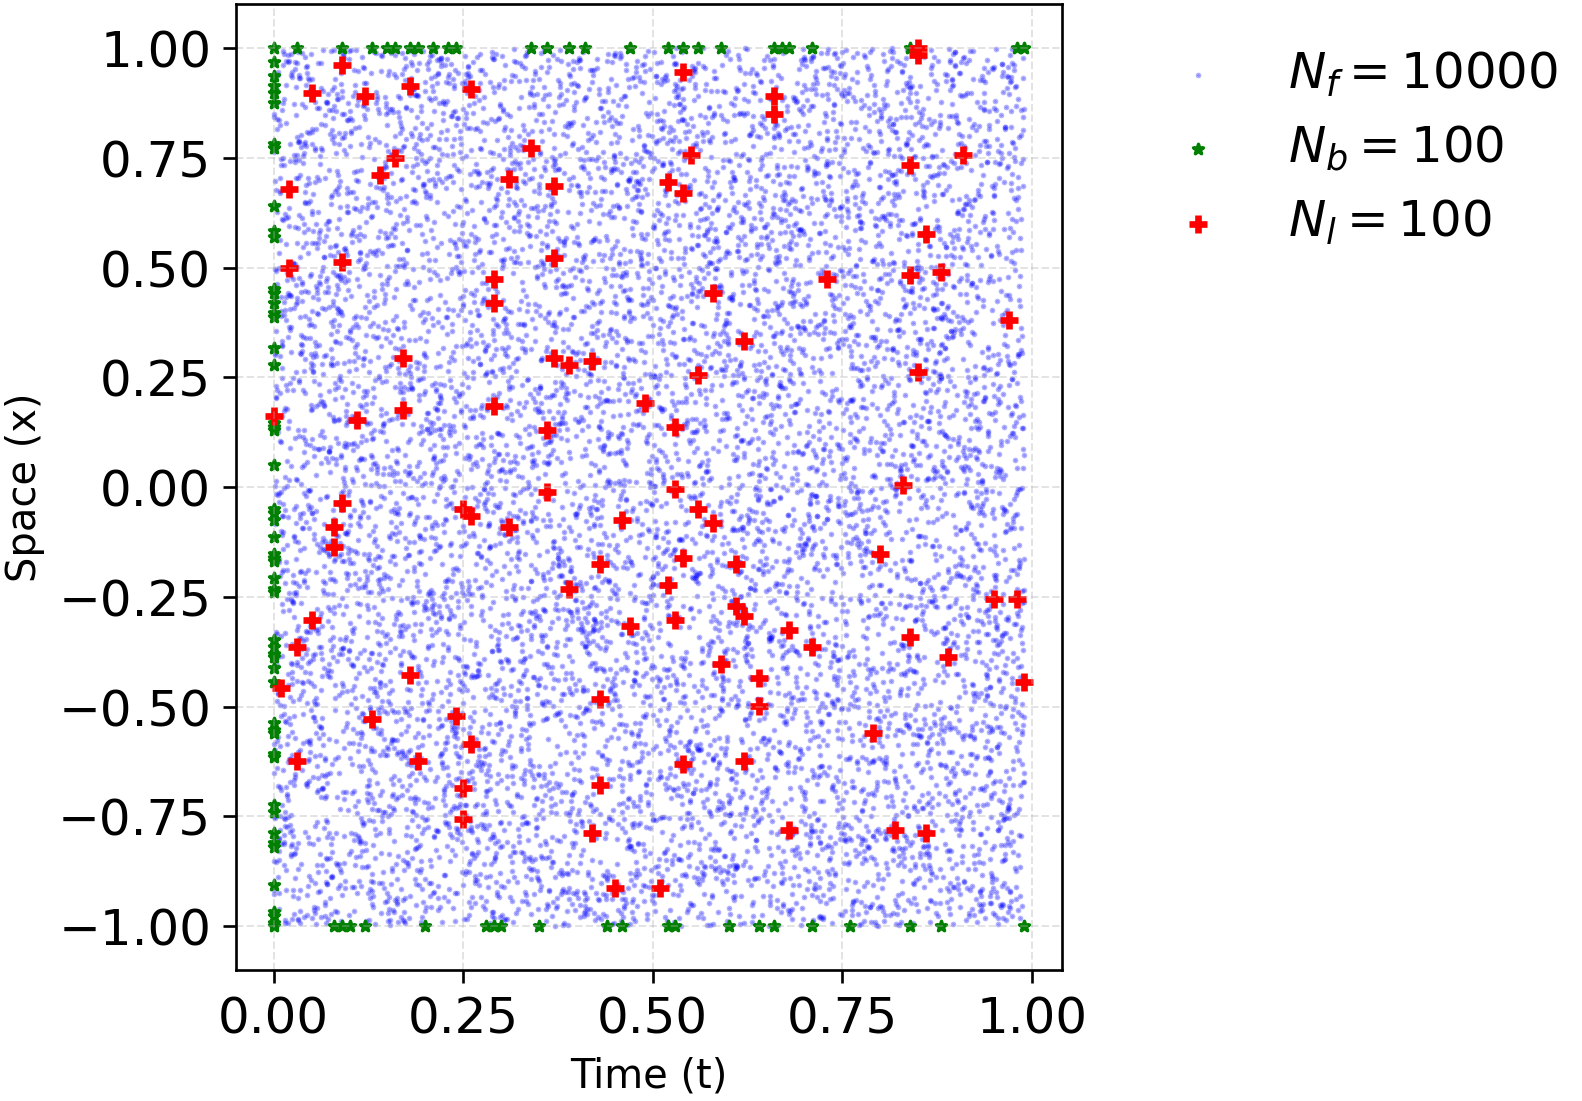

In [15]:


# Training data
# # X_f_train, X_u_train, u_train , X_labelled, u_labelled = trainingdata(N_b, N_f, N_l)

# fig, ax = plt.subplots()

# plt.plot(X_u_train[:,1], X_u_train[:,0], '*', color = 'green', markersize = 5, label = f'Boundary Points = {N_b}')
# plt.plot(X_f_train[:,1], X_f_train[:,0], 'o', markersize = 0.5, label = f'PDE Residuals = {N_f}')
# plt.plot(X_labelled[:,1], X_labelled[:,0], 'P', color = 'red', markersize = 1, label = f'PDE Labelled = {N_l}')
# plt.xlabel('t')
# plt.ylabel('x')
# # plt.title('Collocation points')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.savefig(os.path.join(newFolder, 'collocation_points_Burgers.png'), dpi = 500, bbox_inches='tight')
# plt.show()

fig, ax = plt.subplots(figsize=(7,5))

# Residual points (blue, faint)
ax.scatter(X_f_train[:,1], X_f_train[:,0], 
           s=0.5, c='blue', alpha=0.3, label=fr"$N_f = {N_f}$")

# Boundary points (green stars)
ax.scatter(X_u_train[:,1], X_u_train[:,0], 
           s=10, c='green', marker='*', label=fr"$N_b = {N_b}$")

# Labelled points (red squares)
ax.scatter(X_labelled[:,1], X_labelled[:,0], 
           s=30, c='red', marker='+', label=fr"$N_l = {N_l}$")

# Axis labels
ax.set_xlabel('Time (t)', fontsize=12)
ax.set_ylabel('Space (x)', fontsize=12)

# Legend
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Save figure
fig.savefig('collocation_points_Burgers.png', dpi=500, bbox_inches='tight')
plt.show()


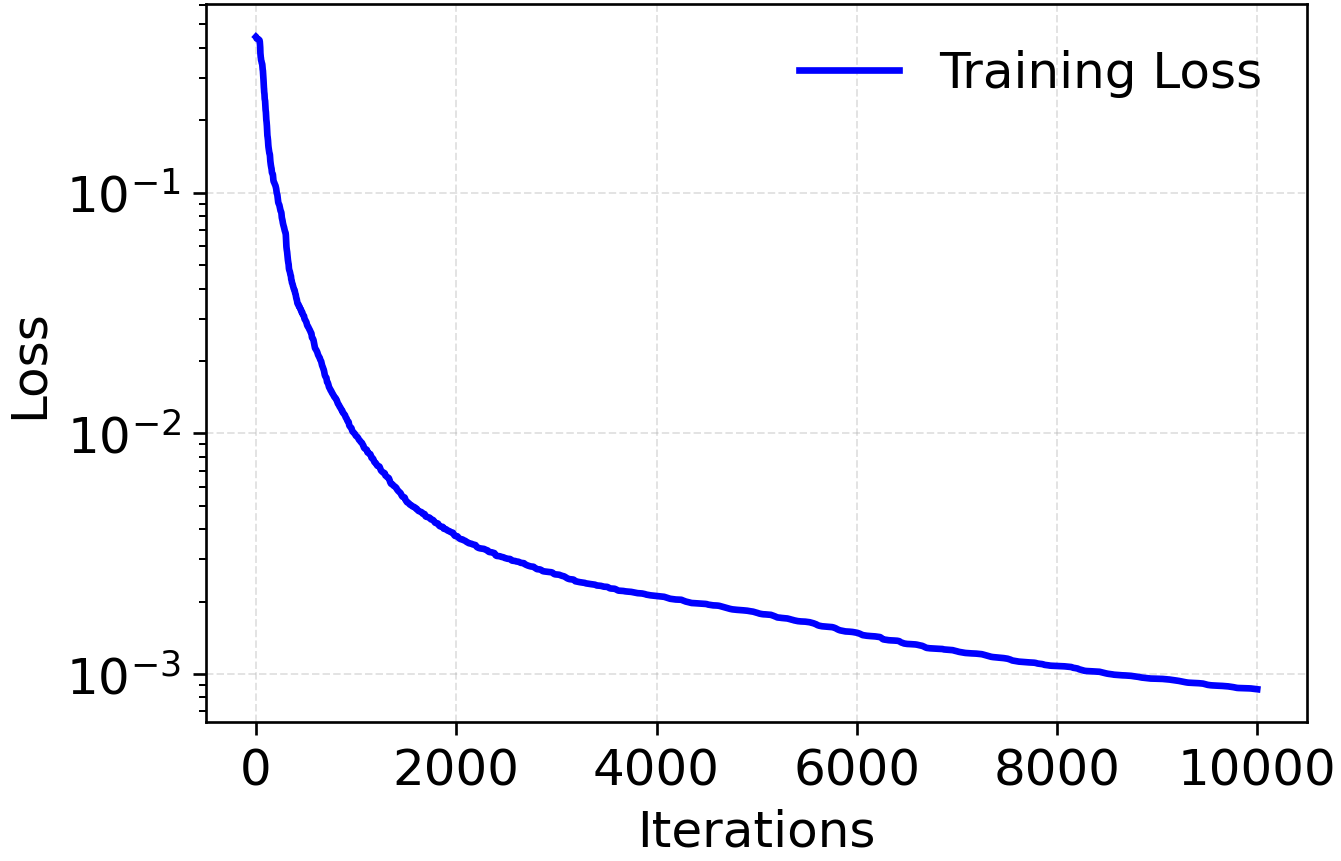

In [16]:
# PINN.losss_history
fig, ax = plt.subplots()  
ax.plot(PINN.losss_history, 'b')

ax.set_xlabel('Iterations')
ax.set_ylabel('Loss')
ax.set_yscale('log')   

plt.legend(['Training Loss'])
plt.savefig(os.path.join(newFolder, 'Loss.png'))
plt.show()

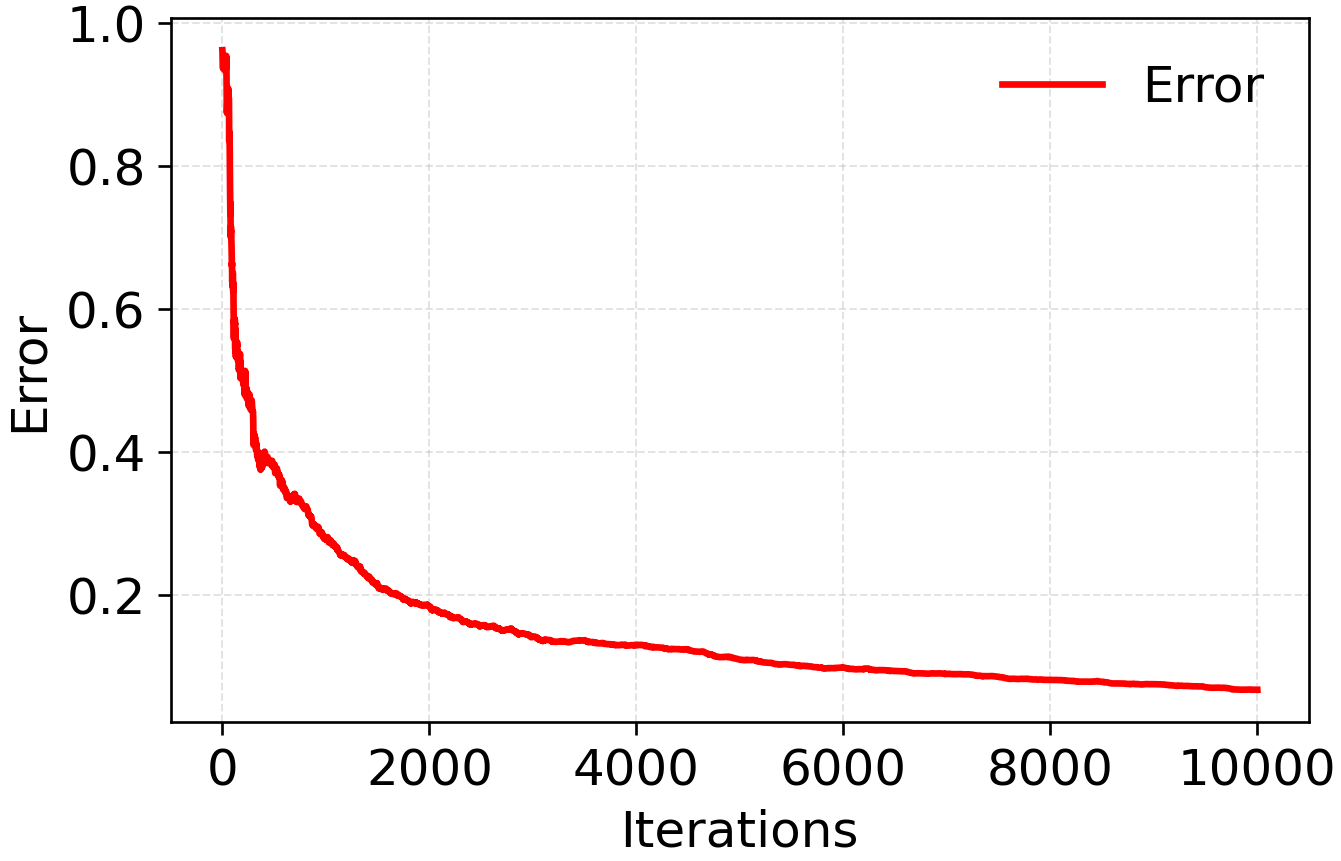

In [17]:
# evolution error
fig, ax = plt.subplots()  
ax.plot(PINN.error_history, 'r')

ax.set_xlabel('Iterations')
ax.set_ylabel('Error')
  
plt.legend(['Error'])
plt.savefig(os.path.join(newFolder, 'Error history.png'))
plt.show()


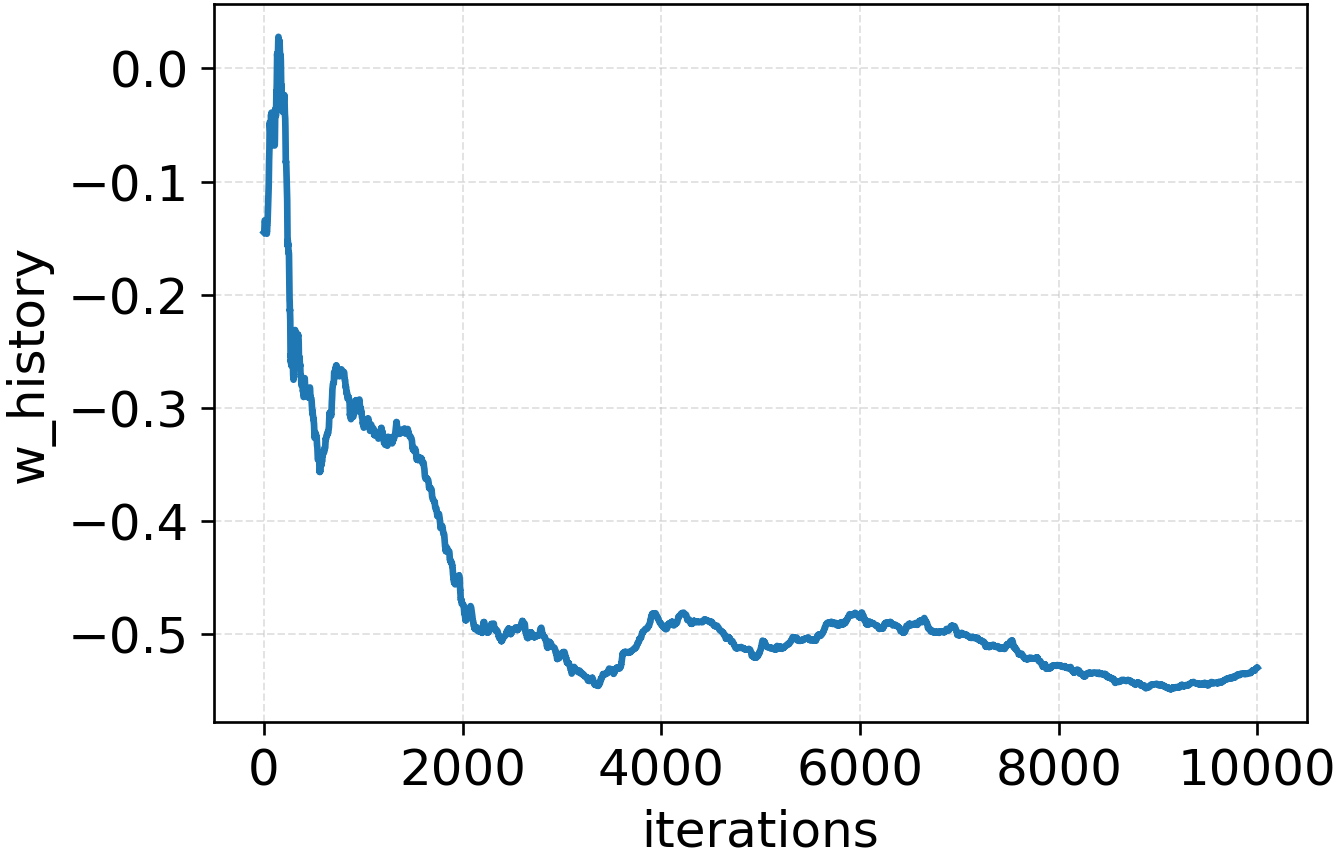

In [18]:
fig, ax = plt.subplots()  
ax.plot(PINN.w_history)
ax.set_xlabel('iterations')
ax.set_ylabel('w_history')
# ax.grid(True)
  
# ax.set_title('training history of the first weight in the NN\n', fontsize = 14)
plt.savefig(os.path.join(newFolder, 'w_history.png'))
plt.show()

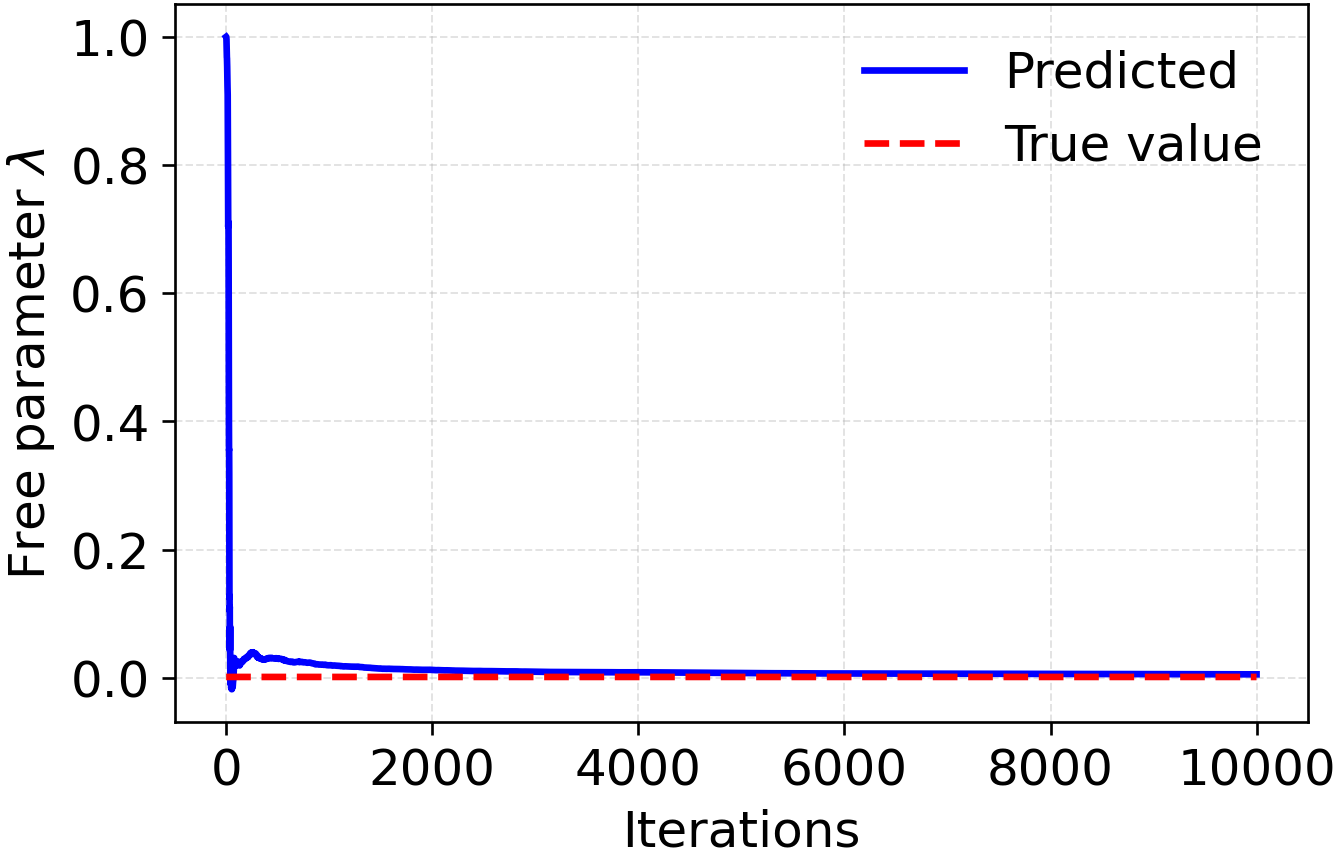

In [19]:
fig, ax = plt.subplots()  
ax.plot(PINN.lambda2_history, 'b')
ax.plot(0.5*0.0031830989 * np.ones_like(PINN.lambda2_history), 'r--')

ax.set_xlabel('Iterations')
ax.set_ylabel(r'Free parameter $\lambda$')
  
plt.legend(['Predicted', 'True value'])
plt.show()

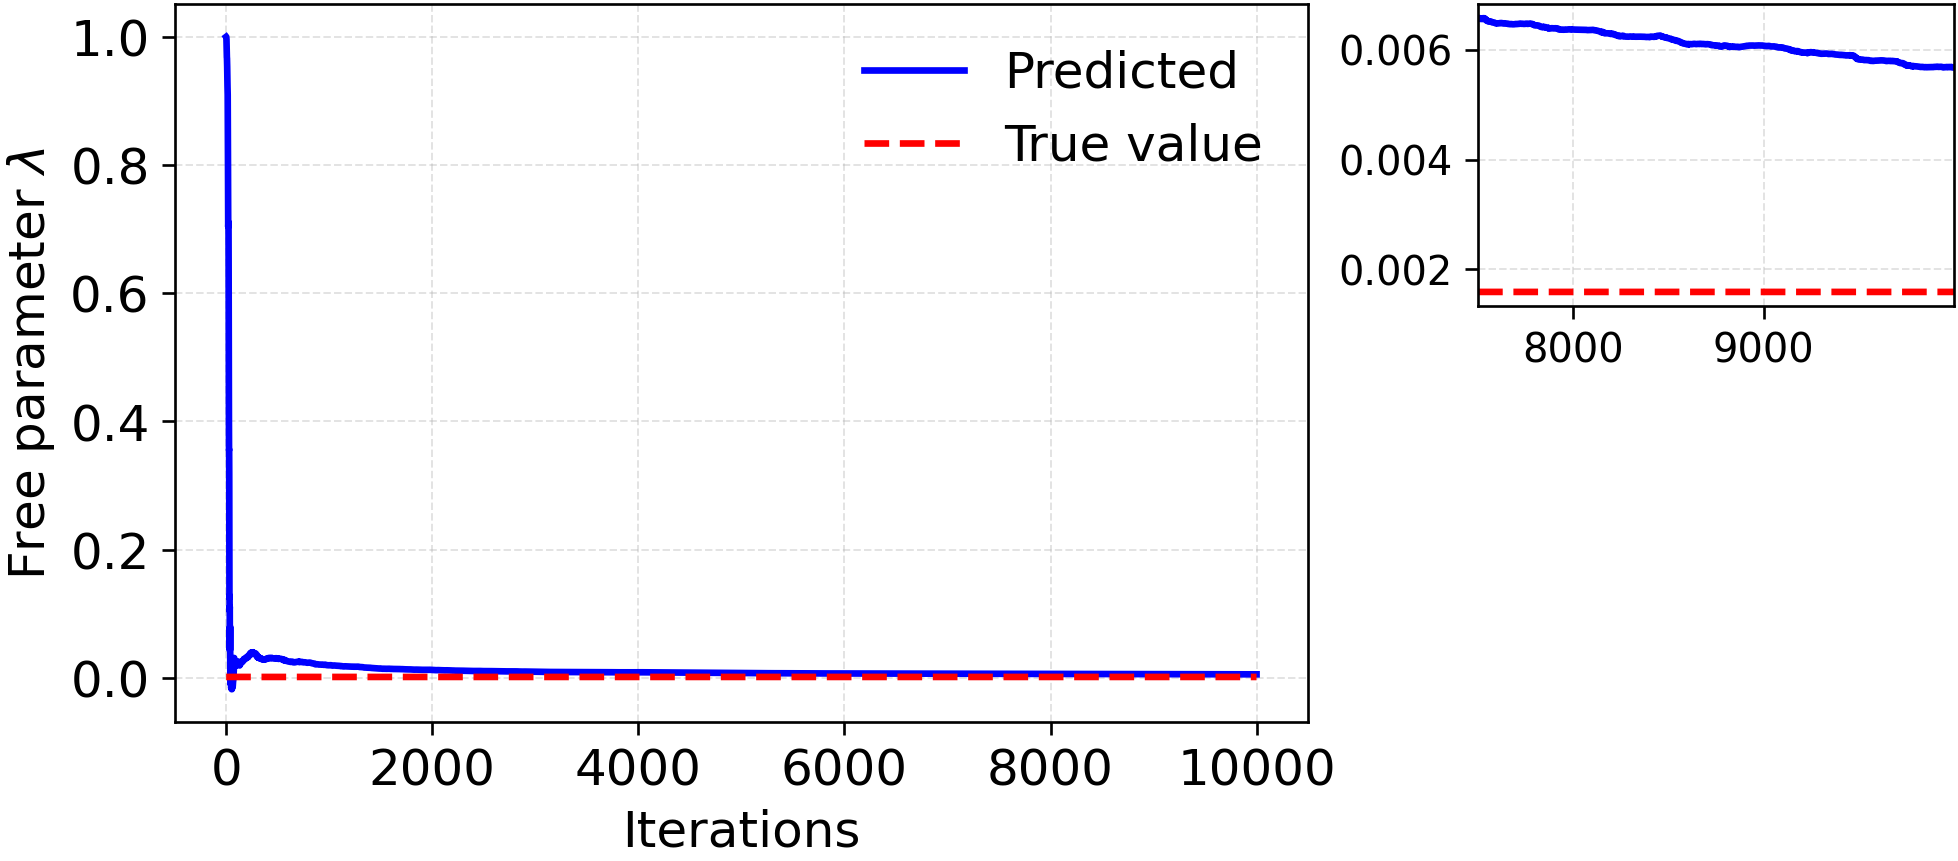

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Data
history = np.asarray(PINN.lambda2_history).reshape(-1)
true_val = 0.5 * 0.0031830989

# Main plot
fig, ax = plt.subplots()
ax.plot(history, 'b', label='Predicted')
ax.plot(np.full_like(history, true_val), 'r--', label='True value')

# Labels (every phrase first letter capital) and no title
ax.set_xlabel('Iterations')
ax.set_ylabel(r'Free parameter $\lambda$')

# Legend
ax.legend()

# --- Inset: last 25% of iterations, placed OUTSIDE ---
start = int(0.75 * len(history))
x_in = np.arange(start, len(history))

# inset placed just outside the right of main axes
axins = inset_axes(
    ax,
    width="42%", height="42%",
    loc="upper left",
    bbox_to_anchor=(1.15, 0.0, 1.0, 1.0),   # 4-tuple for relative placement
    bbox_transform=ax.transAxes,
    borderpad=0.0
)

axins.plot(x_in, history[start:], 'b')
axins.plot(x_in, np.full(len(x_in), true_val), 'r--')

# y-limits with padding
ymin = min(np.min(history[start:]), true_val)
ymax = max(np.max(history[start:]), true_val)
pad = 0.05 * (ymax - ymin if ymax > ymin else 1.0)
axins.set_xlim(x_in[0], x_in[-1])
axins.set_ylim(ymin - pad, ymax + pad)

# Cleaner inset ticks
axins.tick_params(axis='both', which='both', labelsize=12)

plt.show()


ValueError: x and y must have same first dimension, but have shapes (6000,) and (8000,)

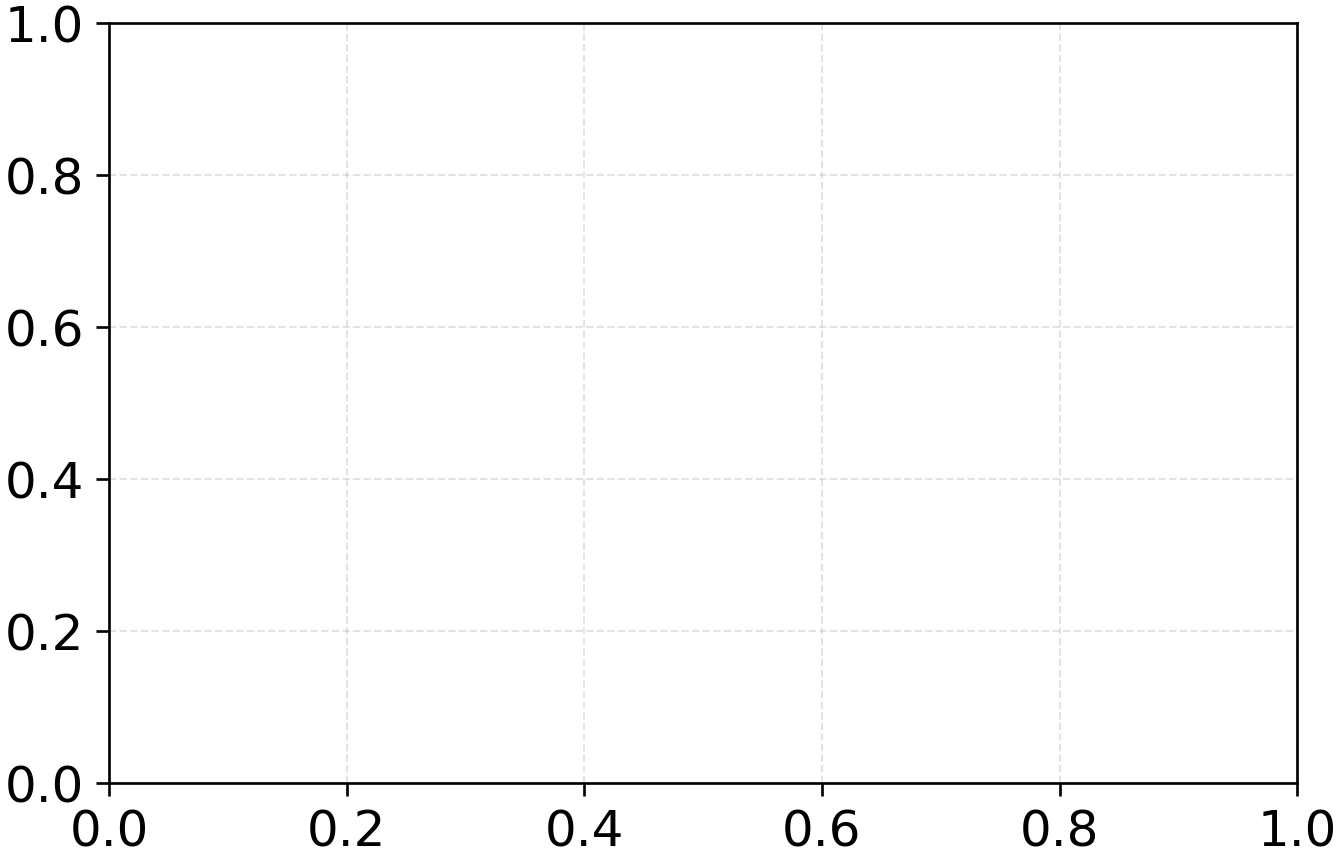

In [21]:
fig, ax = plt.subplots()  
# ax.plot( PINN.lambda2_history, 'b')
ax.plot(range(2000, 8000), PINN.lambda2_history[2000:], 'b')
ax.plot(range(2000, 8000), 0.5*0.0031830989 * np.ones_like(PINN.lambda2_history[2000:]), 'r')
# ax.set_ylim(0, 5)
ax.set_xlabel('iterations')
ax.set_ylabel('lamda1')
# ax.grid(True)
  
ax.set_title('evolution of lambda2\n', fontsize = 14)
plt.legend(['predicted', 'exact'])
plt.savefig(os.path.join(newFolder, 'lambda2_history_magnified.png'))
plt.show()

In [ ]:
print(f'        *RUN INFORMATION*{foldername}')
print('seed:', seed)
print('layers:', layers)
print('N_f:', N_f, 'N_b:', N_b, 'N_l:', N_l)
print('max iteration:', maxiter)
print('')
print('run time:', elapsed/60.0, '(m)')
print(f'lambda2={PINN.lambda2[0].numpy()}')
print('training loss:', PINN.losss_history[-1])
print(f'error: {PINN.error_history[-1]}')


with open(os.path.join(newFolder, foldername+'.txt'), 'w') as file:    
    file.write(f'seed: {seed}\n')
    file.write(f'layers: {layers}\n')
    file.write(f'N_f:, {N_f}, N_b:, {N_b}, N_l:, {N_l}\n')
    file.write(f'max iteration: {maxiter}\n')
    file.write(f'\n')
    file.write(f'run time: {elapsed/60.0}(min)\n')
    file.write(f'lambda2=, {PINN.lambda2[0].numpy()}\n')
    file.write(f'training loss: {PINN.losss_history[-1]}\n')   
    file.write(f'error:, {PINN.error_history[-1]}\n')

        *RUN INFORMATION*run6_minus_initial
seed: 3
layers: [ 2 15 15 15 15  1]
N_f: 10000 N_b: 100 N_l: 10000
max iteration: 8000

run time: 84.58126571575801 (m)
lambda2=0.004700294330712996
training loss: 0.0012099773841790069
error: 0.03970623424824947
